In [1]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["DejaVu Serif"]

import pandas as pd 
import numpy as np 
import os 
import importlib

import cleaning as clean
import abc_models 
import synthetic_data
import tolerance
import helpers

importlib.reload(synthetic_data); importlib.reload(abc_models); importlib.reload(helpers); importlib.reload(tolerance);

WARNING: code has had a lot of changes, have tried to document as I go and thus some things may be missing/outdated. The main results are in section 6 (finding the best tolerance and then testing the classifier works). 

Most logic is found in `abc_models.py`. Helper functions are in `helpers.py`, and `cleaning.py` is the old cleaning function only used in the cell below. The `tolerance.py` file contains only one function for finding the optimal tolerance.

#### 1. Load the signature data, use the cleaning functions.

In [10]:
data_path_signatures = os.path.abspath("../../data/Context_SBS_2.txt")
sig_df = pd.read_csv(data_path_signatures, sep = ",")
clean_sig_df = clean.clean_sigs(sig_df)
clean_sig_df.head(1)

,Context,SBS88,SBS1,SBS5,SBS18,Normal,Mutation
0,A[C>A]A,1.000000e-18,0.000876,0.011998,0.051534,0.015456,C>A


---

#### 2. Check the function `compare_alpha()` works as intended, then look at `abc_alpha_inference()`.

It takes an injection level, a baseline signature, and tests the hypothesis that this baseline signature was derived from the profile $\alpha SBS88 + (1-\alpha)healthyColon$.

In [41]:
# Test the ABC alpha comparison.
healthy_profile = clean_sig_df["Normal"]
sbs88_profile = clean_sig_df["SBS88"]
test_sig = synthetic_data.generate_signature(healthy_profile, N_muts = 100)

abc_models.compare_alpha(test_sig, healthy_profile, sbs88_profile,
                         alpha = 0.5, N_muts = 100, tol = 0.25)

np.float64(0.014)

Low probability --> it is unlikely our healthy signature was derived with $\alpha = 0.5$. This idea is generalised in the `abc_alpha_inference()` wherein we normalise the probabilities that a signature was generated **across a range of** $\alpha$'s.

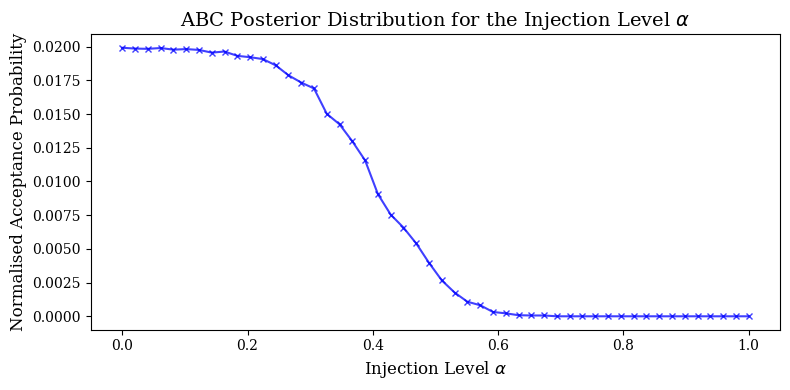

In [4]:
# EXAMPLE WITH 100 MUTATIONS, test signature is HEALTHY (alpha = 0).
importlib.reload(abc_models);
_, _ = abc_models.old_abc_alpha_inference(test_sig, healthy_profile, sbs88_profile, N_muts = 100, plot = True)

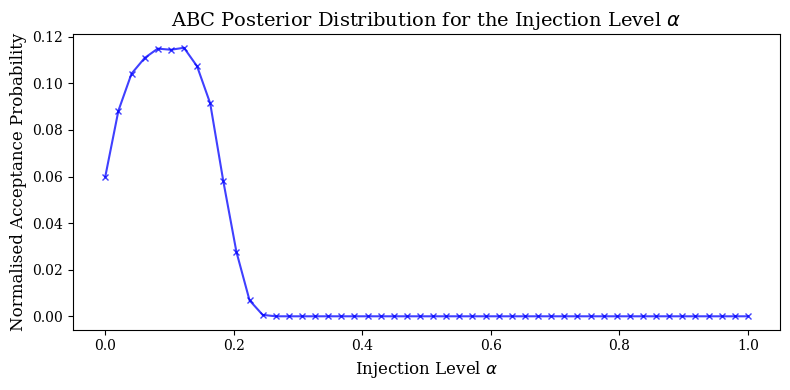

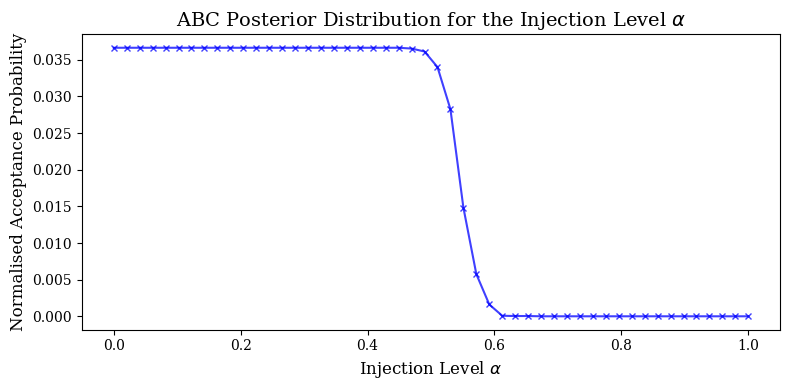

In [38]:
# ANOTHER EXAMPLE WITH 1000 MUTATIONS, TEST SIGNATURE HAS ALPHA = 0.01
# IMPORTANTLY HERE WE VARY THE TOLERANCE (IT IS IMPORTANT!)
importlib.reload(synthetic_data); importlib.reload(abc_models);
alpha01_profile = synthetic_data.composite_profile(healthy_profile, sbs88_profile, alpha = 0.1)
test_sig2 = synthetic_data.generate_signature(alpha01_profile, N_muts = 1000)

__, __ = abc_models.old_abc_alpha_inference(test_sig2, healthy_profile, sbs88_profile, N_muts = 1000, tol = 0.025, plot = True)
__, __ = abc_models.old_abc_alpha_inference(test_sig2, healthy_profile, sbs88_profile, N_muts = 1000, tol = 0.25, plot = True)

Discussion: it works as expected, but the choice of tolerance is very important. (Next section discusses how we can choose the optimal tolerance). 

To obtain more of a "classifier", or similar, we should look to construct confidence intervals for $\alpha$ arising from the posterior. If confidence interval doesn't include zero, that indicates significant evidence SBS88 is present.

---
---

#### 3. Find the optimal tolerance through TPR - FPR analysis.

Expect the tolerance to decrease as the number of mutations increases, want to see how it behaves across different alphas.

NOTE: The TPR - FPR analysis here is not a genuine "TPR - FPR" because there's no classifier going on. It's actually measuring the distances in some sense. See later (section 6) for actual TPR - FPR analysis (you can discount this section, I've only kept it because it's nice for a comparison).

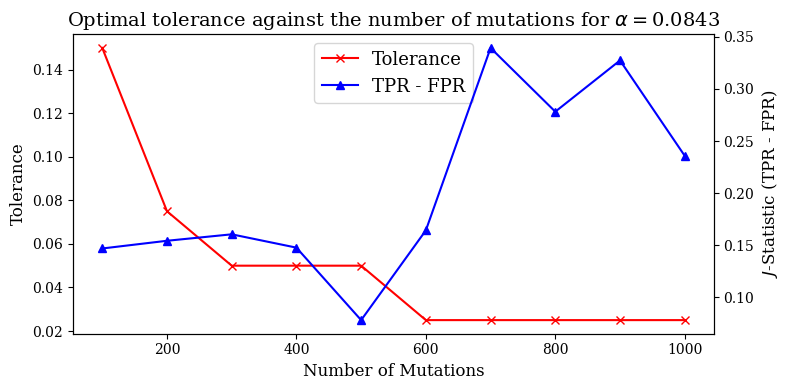

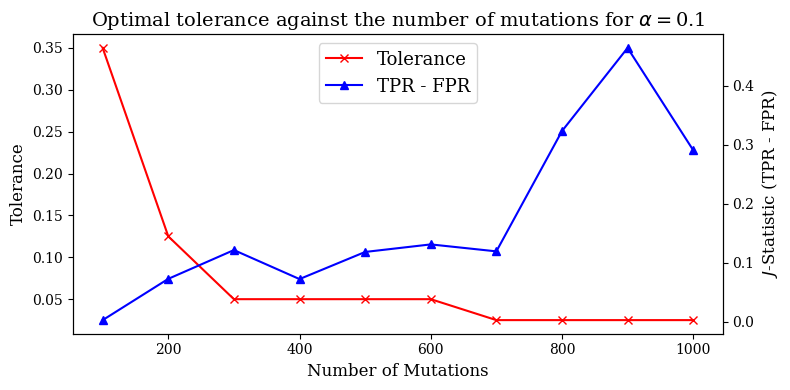

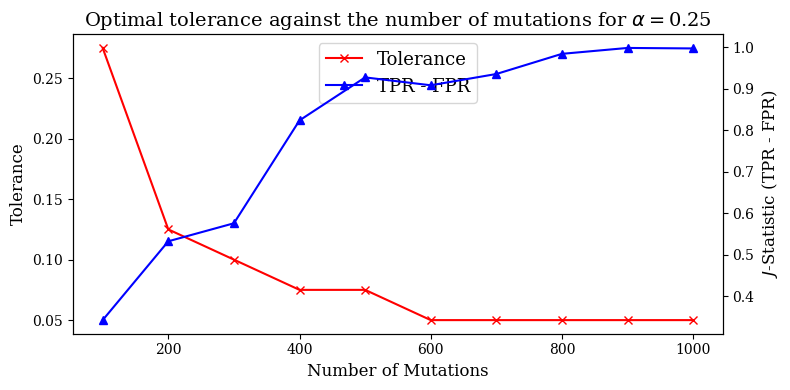

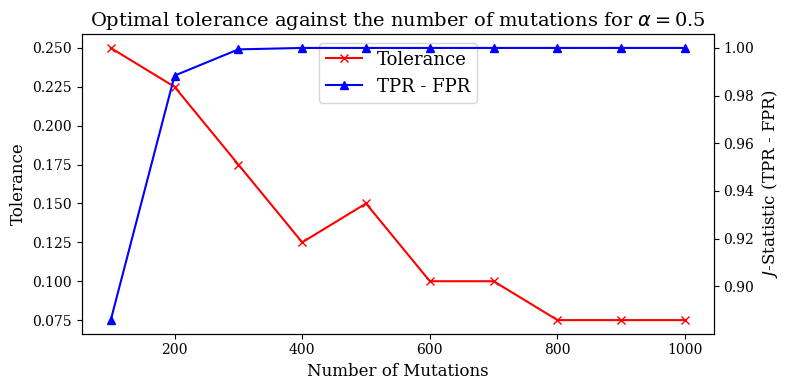

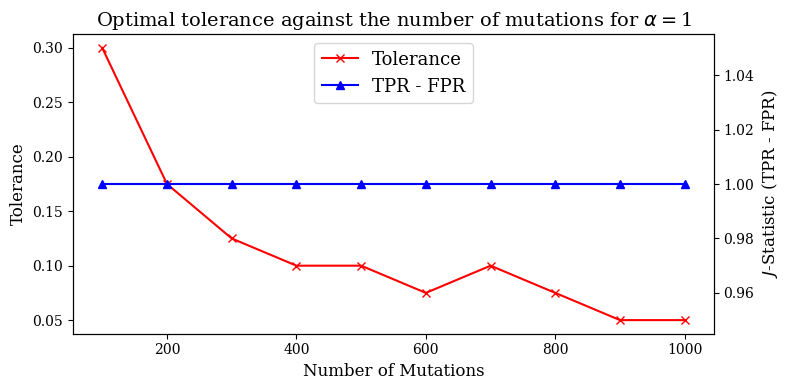

In [9]:
N_muts_range = np.arange(100, 1000 + 100, 100) # 100, 200, ..., 1000
for alpha_test in [0.0843, 0.1, 0.25, 0.5, 1]:
    abc_models.old_optimal_alpha_tol(healthy_profile, sbs88_profile, alpha_test, N_muts_range, plot = True)

In general, best tolerance decreases when we have higher resolution (higher number of mutations). Unfortunately it's very noisy for $\alpha = 0.0843$, try again with more mutations?

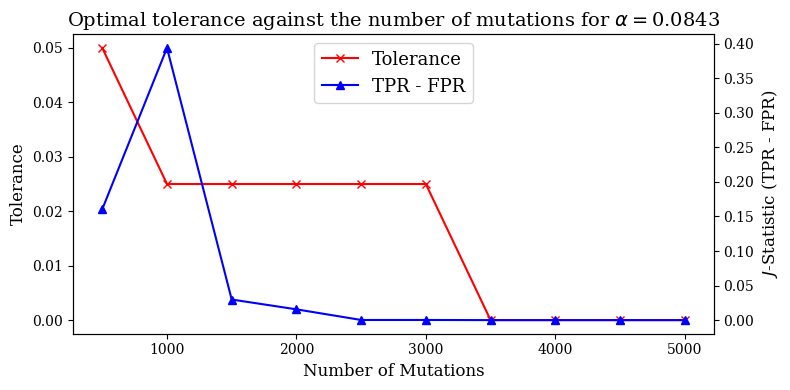

In [10]:
N_muts_alpha0843 = np.arange(500, 5000 + 500, 500)
__ = abc_models.old_optimal_alpha_tol(healthy_profile, sbs88_profile, alpha = 0.0843, N_muts_range = N_muts_alpha0843, plot = True)

Score vanishes! Why? Maybe because $\alpha$ is too low and we cannot differentiate between the signatures at all? Plot the signatures generated from a healthy signature and a low-$\alpha$ signature to see why this might be happening?

##### NOTE Plots of this type might be nice for the report.

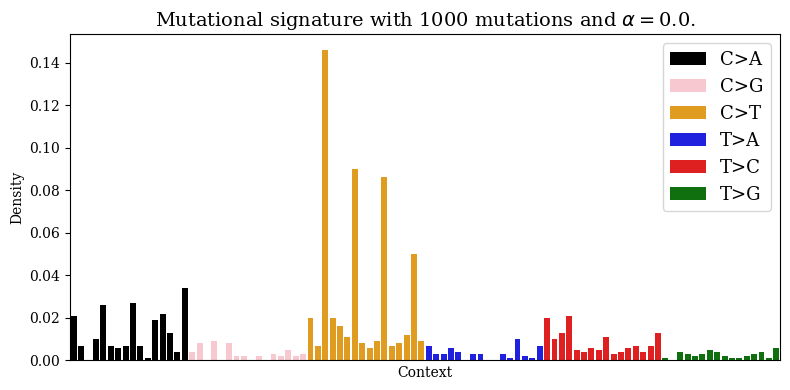

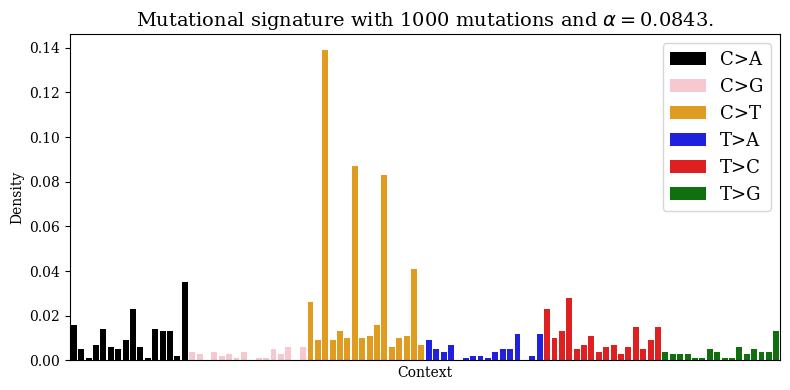

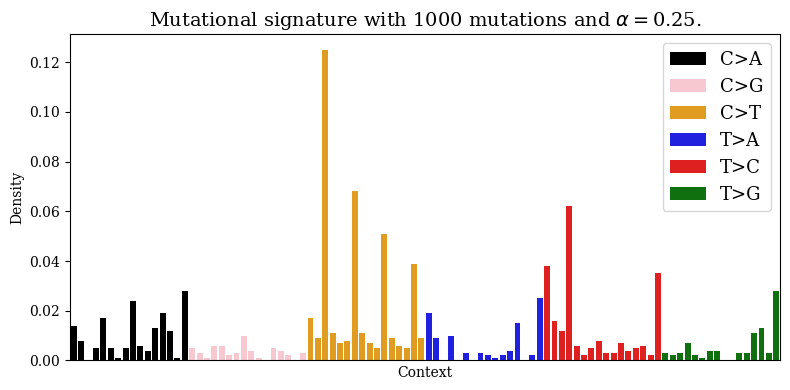

In [11]:
importlib.reload(synthetic_data);
contexts = clean_sig_df["Context"]
mutations = clean_sig_df["Mutation"]

# Infected profile alpha = 0.0843
alpha0843_profile = synthetic_data.composite_profile(healthy_profile, sbs88_profile, alpha = 0.0843)
alpha25_profile = synthetic_data.composite_profile(healthy_profile, sbs88_profile, alpha = 0.25)

N_muts = 1000
healthy_sig = synthetic_data.generate_signature(healthy_profile, N_muts)
infected_sig = synthetic_data.generate_signature(alpha0843_profile, N_muts)
infected_sig2 = synthetic_data.generate_signature(alpha25_profile, N_muts)

synthetic_data.plot_signature(contexts, mutations, healthy_sig, N_muts = 1000, alpha = 0.0)
synthetic_data.plot_signature(contexts, mutations, infected_sig, N_muts = 1000, alpha = 0.0843)
synthetic_data.plot_signature(contexts, mutations, infected_sig2, N_muts = 1000, alpha = 0.25)

Because SBS88 is dominated by T>C mutations, low levels of $\alpha$ make the signature **as a whole, across all 96 contexts** very similar. It might be worth doing the analysis **just on the T>C contexts**? Think this is something Xell suggested a few weeks ago.

Also: should store information for the mutational profiles of commonly used values of $\alpha$. Same goes for the tolerances.

In [21]:
importlib.reload(synthetic_data);
mutational_profiles = synthetic_data.create_mutational_profiles(healthy_profile, sbs88_profile)
mutational_profiles.keys()
# NOTE Should revisit the tolerance finding and save that data too
# (takes about 5mins to run).

dict_keys([0, 0.0843, 0.1, 0.25, 0.5, 0.8, 1])

#### 4. Constructing highest density intervals using ABC-alpha rejection.

Currently we can plot the posterior, but all inference is done visually. We want to have a formal metric that says "$\alpha$ is very likely to be in THIS RANGE", i.e. a form of confidence interval.

Highest density intervals (HDIs) are just narrowest range of parameters (here the smallest range of $\alpha$) that contain a certain percentage of the total probability mass (here we'll default to 90%).

True alpha =  0.25, lots of mutations (500).


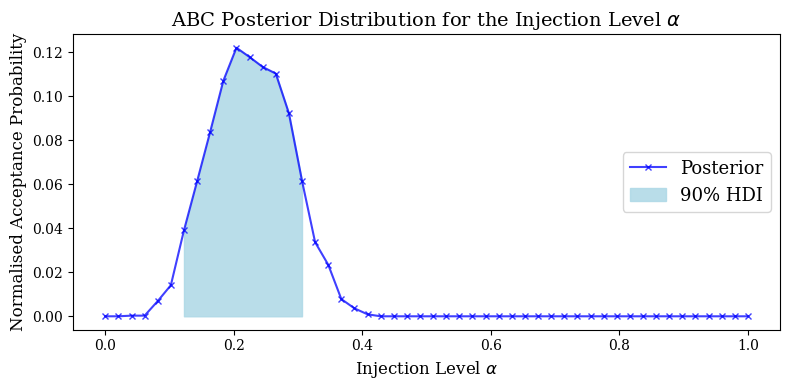

In [72]:
# EXAMPLE of posterior found from the abc-alpha.
# Tolerance found by inspection of earlier plots.
importlib.reload(abc_models);
alpha_test = 0.25; N_muts_test = 500; tol_test = 0.05;
test_sig = synthetic_data.generate_signature(mutational_profiles[alpha_test], N_muts_test)
print(rf"True alpha =  {alpha_test}, lots of mutations ({N_muts_test}).")
acceptances, alpha_range, alpha0, alpha1, alpha_mode, hdi_mass = abc_models.abc_alpha_inference(test_sig, healthy_profile, sbs88_profile, N_muts = N_muts_test, tol = tol_test, plot = True)

In [73]:
importlib.reload(abc_models);
abc_models.hdi(acceptances, alpha_range)

(np.float64(0.12244897959183673),
 np.float64(0.3061224489795918),
 np.float64(0.9088995790739628))

True alpha =  0.0843, small number of mutations (100).


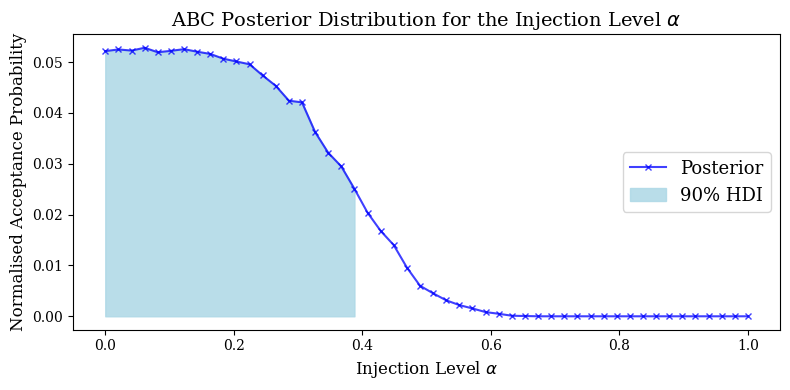

In [74]:
alpha_test = 0.0843; N_muts_test = 100; tol_test = 0.25;
test_sig = synthetic_data.generate_signature(mutational_profiles[alpha_test], N_muts_test)
print(rf"True alpha =  {alpha_test}, small number of mutations ({N_muts_test}).")
acceptances, alpha_range, alpha0, alpha1, alpha_mode, hdi_mass = abc_models.abc_alpha_inference(test_sig, healthy_profile, sbs88_profile, N_muts = N_muts_test, tol = tol_test, plot = True)

True alpha =  0.0843, very large number of mutations (2000).
In this example we use more bins for alpha (100 instead of 50).


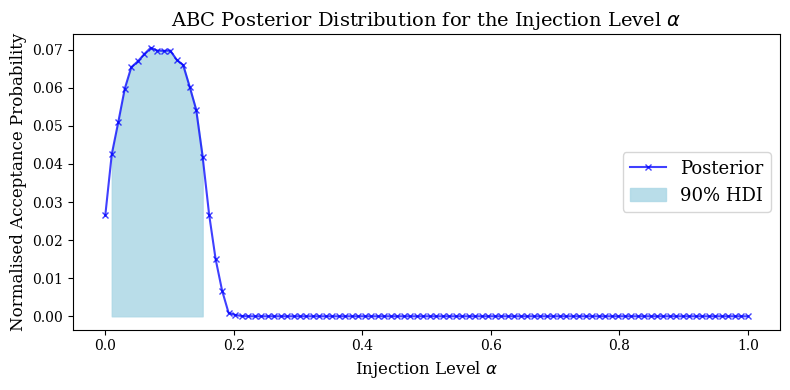

Interval [0.01, 0.15]. Mode 0.07.


In [80]:
importlib.reload(abc_models)
alpha_test = 0.0843; N_muts_test = 2000; tol_test = 0.015;
test_sig = synthetic_data.generate_signature(mutational_profiles[alpha_test], N_muts_test)
print(rf"True alpha =  {alpha_test}, very large number of mutations ({N_muts_test}).")
print(rf"In this example we use more bins for alpha (100 instead of 50).")
acceptances, alpha_range, alpha0, alpha1, alpha_mode, hdi_mass = abc_models.abc_alpha_inference(test_sig, healthy_profile, sbs88_profile, N_muts = N_muts_test, tol = tol_test, a_bins = 100, plot = True)
print(rf"Interval [{round(alpha0, 2)}, {round(alpha1, 2)}]. Mode {round(alpha_mode, 2)}.")

- In the first example, the HDI is far away from zero, so we'd detect the presence of SBS88. 
- In the second example, the HDI includes zero, but also values away from zero, so we'd be wary of detecting any SBS88.
- In the third example, we sometimes include zero, but aren't far from it. Here we'd suggest presence of SBS88 but not be *as* confident about it.

Note: have added the mode for better inference.

---

#### 5. Using the inference for classification.

First idea:
- If $0.05 < \alpha_0$ then confidently suggest the presence of SBS88. Use the mode as an estimate for the injection level.

- If $0 < \alpha_0 < 0.025$, then split into two cases: (a) if $\alpha_1 > 0.1$ AND $\alpha_{\mathrm{mode}} > 0.05$ then suggest the presence of SBS88; otherwise (b) reject.

- If $0 = \alpha_0$, reject the presence of SBS88.

These are just benchmarks I've somewhat arbitrarily set.

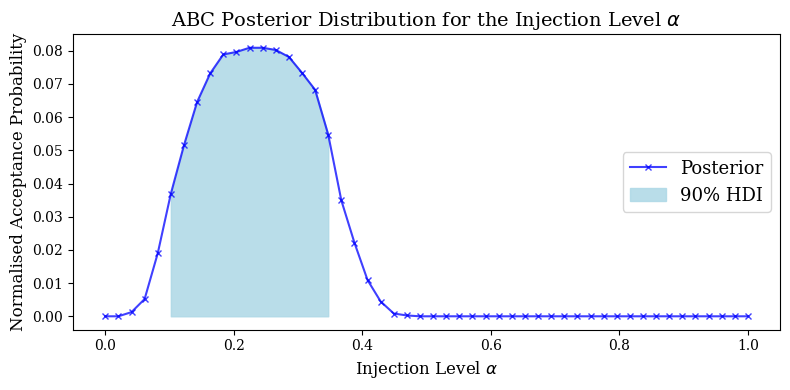

(True, np.float64(0.22448979591836732))

In [83]:
importlib.reload(abc_models);
alpha_test = 0.25; N_muts_test = 500; tol_test = 0.05;
test_sig = synthetic_data.generate_signature(mutational_profiles[alpha_test], N_muts)

abc_models.abc_alpha_classifier(test_sig, healthy_profile, sbs88_profile,
                            N_muts = N_muts_test, tol = tol_test, plot = True)

In [101]:
importlib.reload(abc_models);
alpha_test = 0.0843; N_muts_test = 100; tol_test = 0.025;
test_sig = synthetic_data.generate_signature(mutational_profiles[alpha_test], N_muts)

abc_models.abc_alpha_classifier(test_sig, healthy_profile, sbs88_profile,
                            N_muts = N_muts_test, tol = tol_test, plot = True)

c:\Users\freds\Documents\UoE\Maths\RSCAM\Project\rscam-g6\temp\abc_models.py:184: UserWarning: No value of $\alpha$ was accepted. Try adjusting the tolerance. Here tol = 0.025 with 100 mutations.
  alpha_acceptances = alpha_acceptances / alpha_acceptances.shape[0]


(False, 0.0)

---

#### 6. Use the classifier to once again find the best tolerance range.

Vary the $\alpha$ and the number of mutations presence. Here the TPR/FPR metrics make more sense since we have a genuine binary classifier. The code went through some big changes to vectorise it.

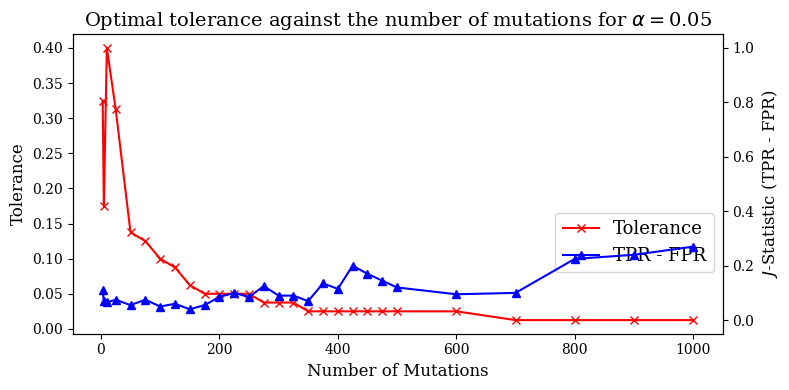

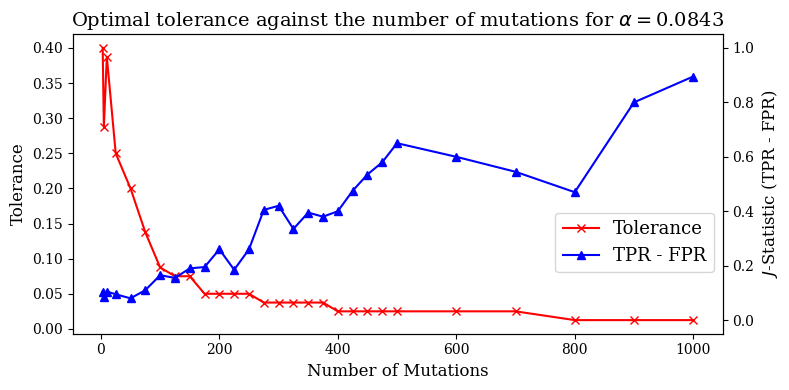

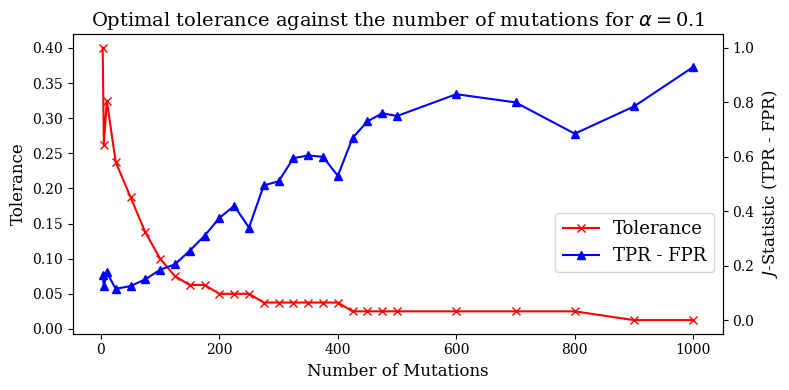

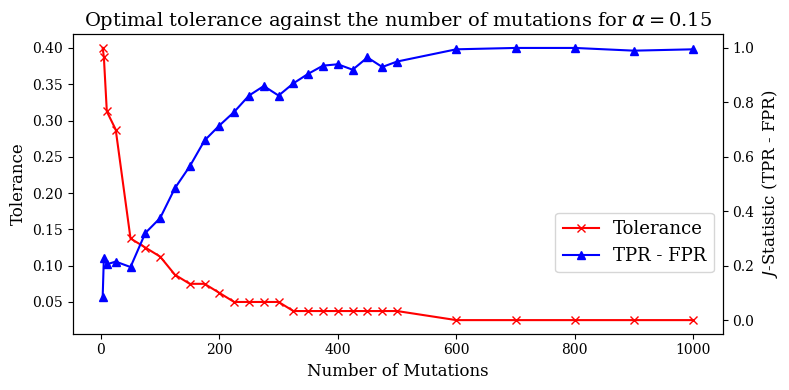

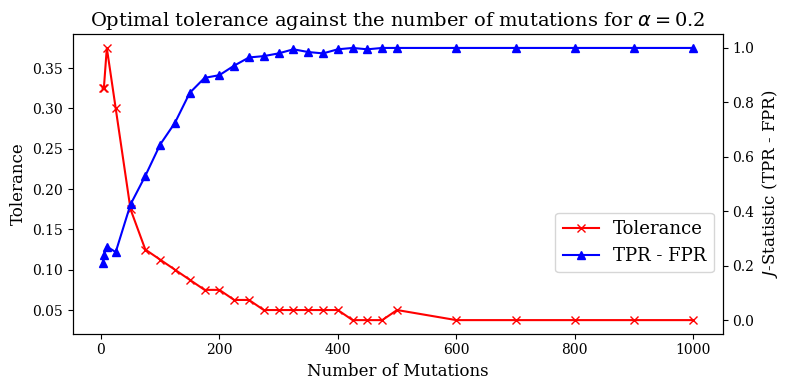

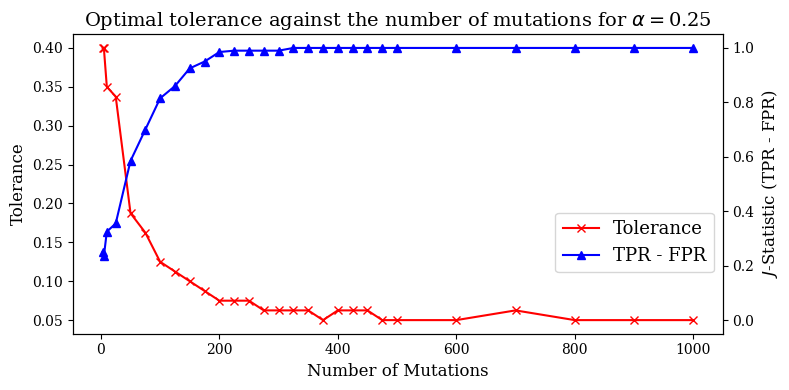

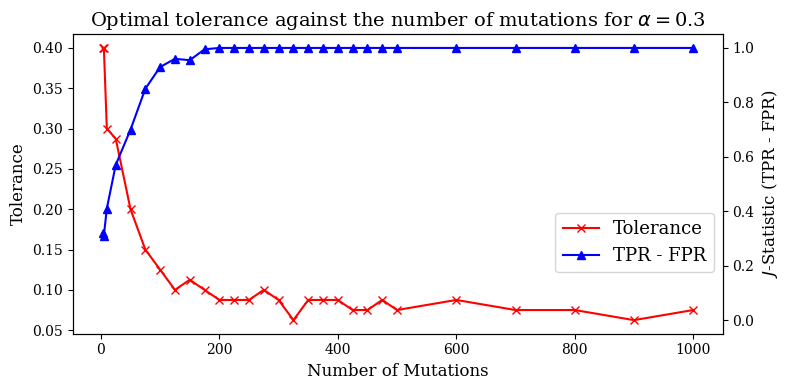

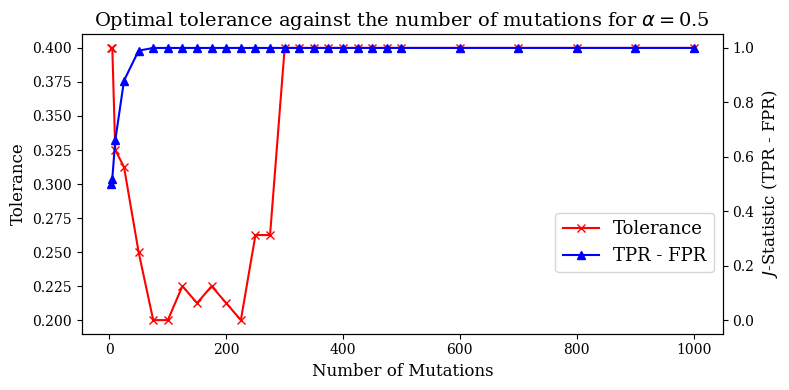

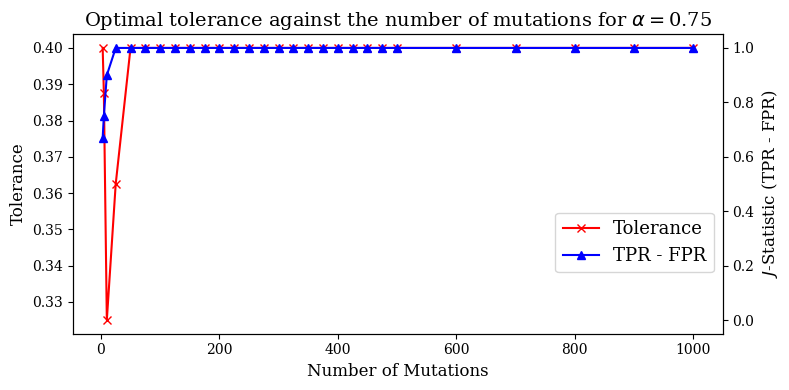

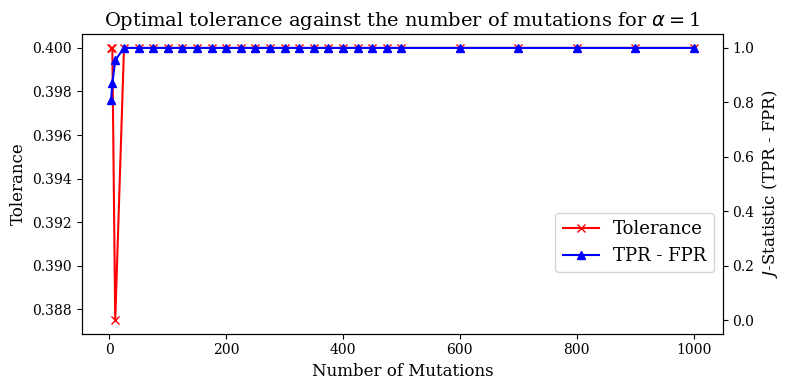

In [53]:
importlib.reload(abc_models); importlib.reload(synthetic_data); importlib.reload(tolerance);
# N_muts_range = np.array([3, 5, 10, 50, 100, 200])
N_muts_range = np.concat(([3, 5, 10, 25], np.arange(50, 500 + 25, 25), np.arange(600, 1000 + 100, 100)))
tol_range_test = np.arange(0.0125, 0.4 + 0.0125, 0.0125)

results_data = []
for alpha_test in [0.05, 0.0843, 0.1, 0.15, 0.2, 0.25, 0.3, 0.5, 0.75, 1]:
    best_tols, best_Js = tolerance.optimal_alpha_tol(healthy_profile, sbs88_profile, alpha_test, 
                                 N_muts_range, tol_range = tol_range_test, plot = True, baseline_comparisons = 200)
    
    for n_mut, tol, j in zip(N_muts_range, best_tols, best_Js):
        results_data.append({'alpha': alpha_test, 'N_muts': n_mut, 'best_tol': round(tol, 4), 'best_J': j})

results_df = pd.DataFrame(results_data)

In [ ]:
# If wanted, rerun and store more values. These should be enough.
# results_df.to_csv("optimal_abc_tolerances.csv", index = False)

#### 6b. Store the best tolerances and do some examples of classification with the synthetic data.

The tolerance is important, but now we have the optimal values. Use the classifier (all found in `abc_models.py`, building on the logic as before) with the best tolerance and see how well it works.

"Generate a synthetic signature with a given $\alpha$ and number of mutations. See if the recovers this well." 

In [105]:
importlib.reload(abc_models); importlib.reload(helpers);
test1_summary = abc_models.test_classifier(healthy_profile, sbs88_profile, alpha_test = 0.25, N_muts_test = 200, trials = 5)
test1_summary

,N_muts,detected,est_alpha
0,5,0.2,0.202020
1,10,0.0,NaN
2,20,0.2,0.232323
3,50,0.6,0.260943
4,100,1.0,0.209192
5,250,1.0,0.221380
6,500,1.0,0.218182


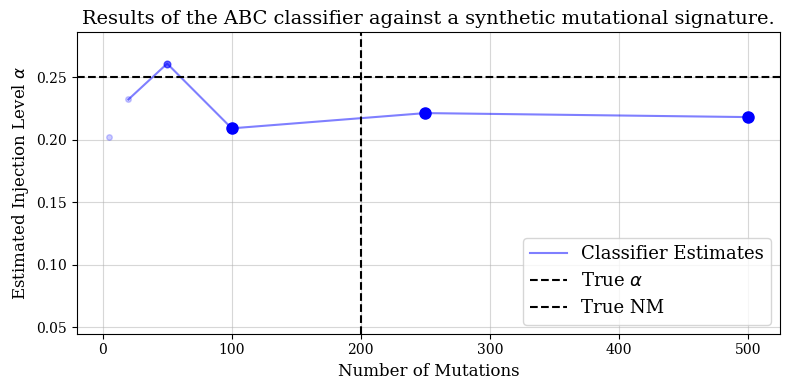

In [127]:
importlib.reload(abc_models);
abc_models.plot_classifier_results(test1_summary, true_alpha = 0.25, true_N_mut = 200)

---

##### More tests for various levels.

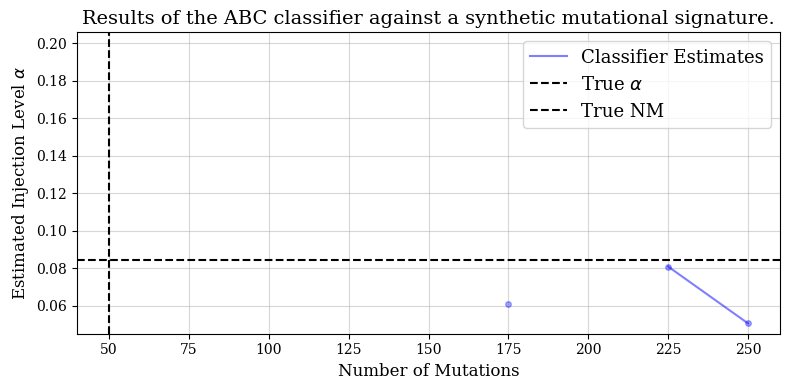

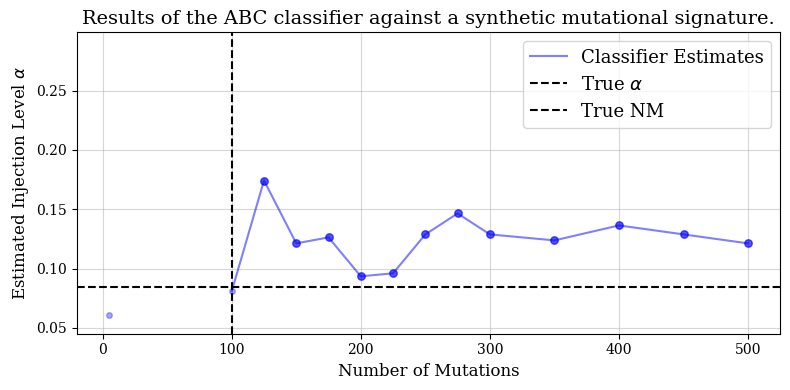

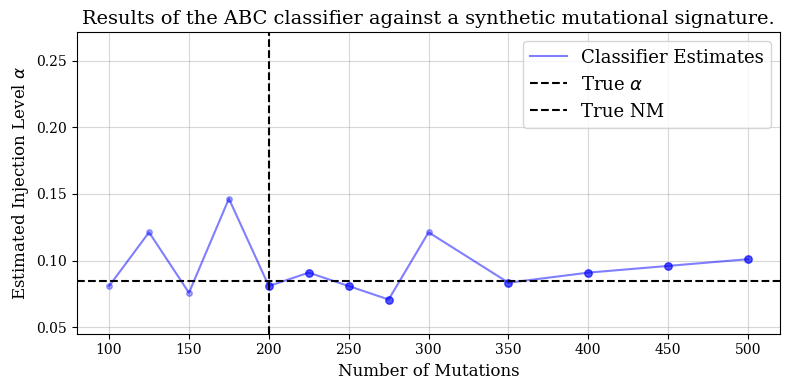

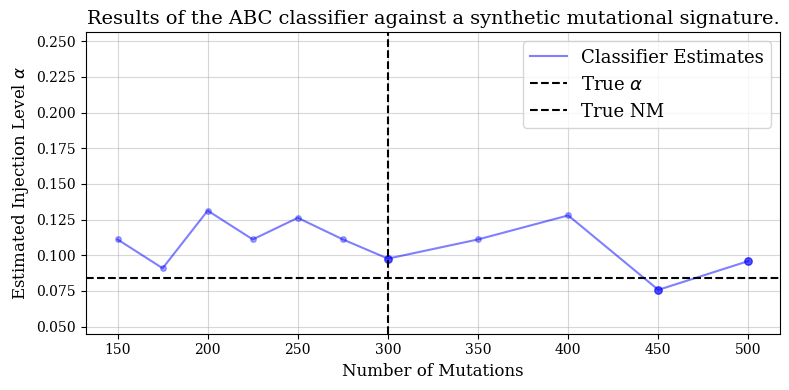

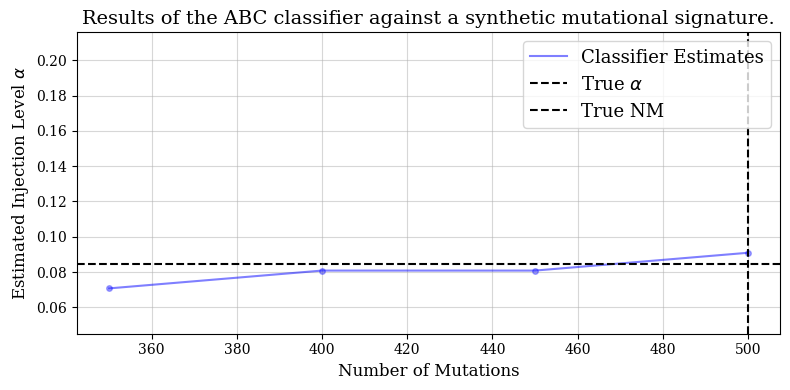

In [135]:
importlib.reload(abc_models)
alpha_tests = [0.0843, 0.0843, 0.0843, 0.0843, 0.0843]
N_muts_tests = [50, 100, 200, 300, 500]
for alpha_test, N_muts_test in zip(alpha_tests, N_muts_tests):
    abc_models.test_classifier(healthy_profile, sbs88_profile, alpha_test, N_muts_test, trials = 3, plot = True)

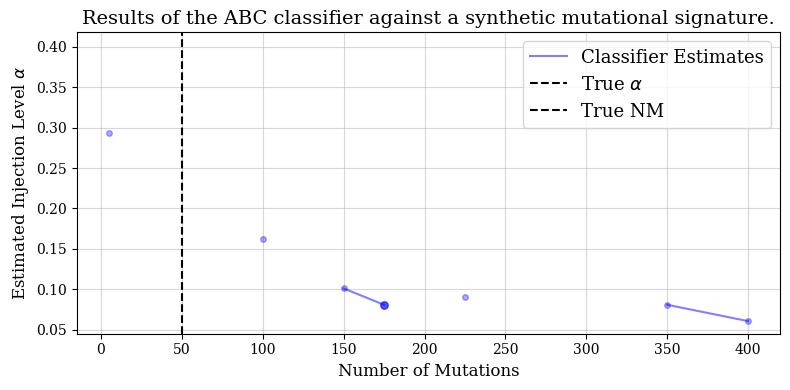

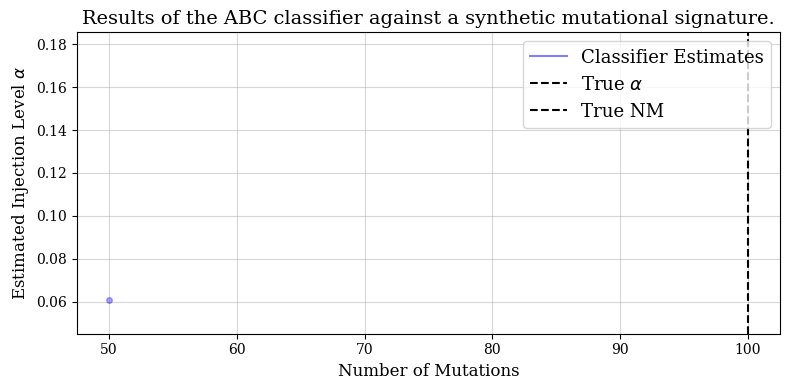

c:\Users\freds\Documents\UoE\Maths\RSCAM\Project\rscam-g6\Notebooks\abc_alpha\abc_models.py:212: UserWarning: No alpha found (all NaN), not plotting. True alpha = 0 with NM = 200.
  warnings.warn(f"No alpha found (all NaN), not plotting. True alpha = {true_alpha} with NM = {true_N_mut}.")
c:\Users\freds\Documents\UoE\Maths\RSCAM\Project\rscam-g6\Notebooks\abc_alpha\abc_models.py:212: UserWarning: No alpha found (all NaN), not plotting. True alpha = 0 with NM = 300.
  warnings.warn(f"No alpha found (all NaN), not plotting. True alpha = {true_alpha} with NM = {true_N_mut}.")
c:\Users\freds\Documents\UoE\Maths\RSCAM\Project\rscam-g6\Notebooks\abc_alpha\abc_models.py:212: UserWarning: No alpha found (all NaN), not plotting. True alpha = 0 with NM = 500.
  warnings.warn(f"No alpha found (all NaN), not plotting. True alpha = {true_alpha} with NM = {true_N_mut}.")


In [5]:
alpha_tests = [0, 0, 0, 0, 0]
N_muts_tests = [50, 100, 200, 300, 500]
for alpha_test, N_muts_test in zip(alpha_tests, N_muts_tests):
    abc_models.test_classifier(healthy_profile, sbs88_profile, alpha_test, N_muts_test, trials = 3, plot = True)

---
---
---

#### 7. Work with just T>C changes instead of the whole profile?

---

#### 8. Look at the real world data, treating signatures i.i.d, and see if we can recover SBS88? 

Note I added a normed count to the df.

In [32]:
cosmic_muts_path = os.path.abspath("../abc_alpha/normed_cosmic_counts.csv")
cosmic_sig_raw = pd.read_csv(cosmic_muts_path)
cosmic_sig_raw.head(1)

,Unnamed: 0,COSMIC96,norm_count
0,0,A[C>A]A,0.005682


In [33]:
cosmic_sig_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  45 non-null     int64  
 1   COSMIC96    45 non-null     object 
 2   norm_count  45 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.2+ KB


In [35]:
cosmic_sig_raw["norm_count"].sum()

np.float64(0.9999999999999973)

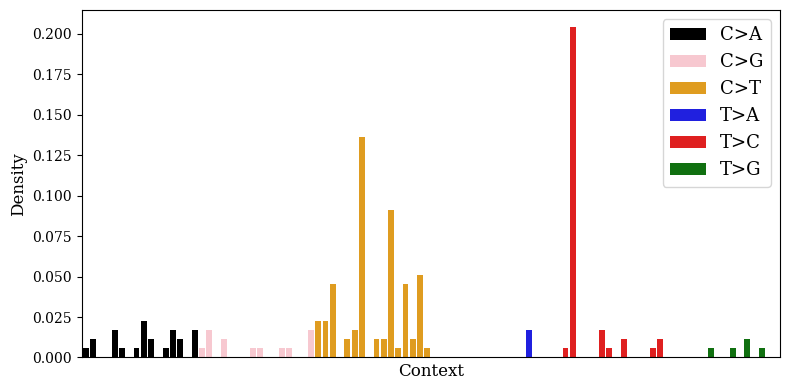

In [60]:
# Problem with this: only 45 of the 96 contexts.
all_contexts = clean_sig_df["Context"]
current_contexts = cosmic_sig_raw["COSMIC96"]

cosmic_sig = np.zeros_like(all_contexts, dtype=float)
lookup_df = cosmic_sig_raw.set_index("COSMIC96")

for j, context in enumerate(all_contexts):
    if context in lookup_df.index:
        cosmic_sig[j] = lookup_df.loc[context, "norm_count"]

# Check still normalised.
assert np.abs(1 - np.sum(cosmic_sig)) < 1e-6

synthetic_data.plot_signature(clean_sig_df["Context"], clean_sig_df["Mutation"], cosmic_sig)

In [56]:
healthy_profile = clean_sig_df["Normal"]
sbs88_profile = clean_sig_df["SBS88"]
detected, estimated_alphas, N_muts_range = abc_models.detect_sbs88(cosmic_sig, healthy_profile, sbs88_profile)
detected_int = np.array(detected, dtype = int)

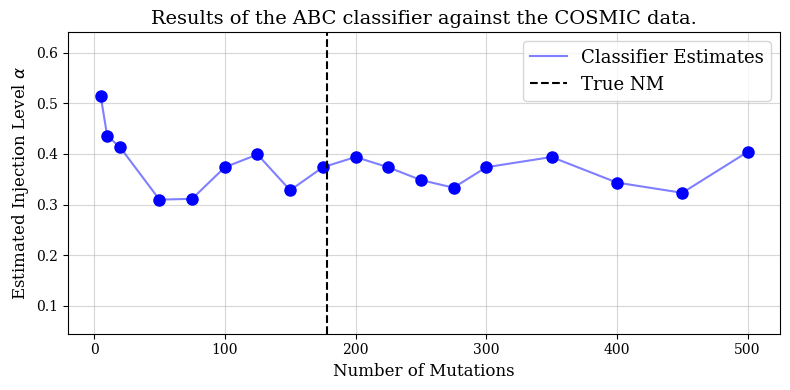

In [61]:
# Combine into a DataFrame
cosmic_result_df = pd.DataFrame({"detected": detected_int, "est_alpha": estimated_alphas, "N_muts": N_muts_range})
title = "Results of the ABC classifier against the COSMIC data."
abc_models.plot_classifier_results(cosmic_result_df, true_N_mut = 178, title = title) # Originally 178 in the data.

---